# 07221203_2025 — good triggered pulses (dumps 2-5)

Series `07221203_2025`, dumps `F0002` through `F0005` (Run76, same series as
`07221203_2025_dump1_noise.ipynb`), pooled together. Same scope: **Detector 0, Channel 0**.
Goal: find several clean, clearly-triggered, comparably-sized pulses and overlay them to
see where the trigger/pulse onset actually falls within the 4096-sample window. Run with
the `darkmatter_cli_env` conda environment.

Uses the shared `python/` library (`pulse_io`/`pulse_quantities`/`pulse_cuts`) instead
of ad-hoc per-trace loops — see `python/README.md` for the conventions.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data

import numpy as np
import matplotlib.pyplot as plt

import pulse_io as pio
import pulse_quantities as pq
import pulse_cuts as pc
from pulse_config import PulseConfig

home_directory = Path.home()
DUMPS = ["F0002", "F0003", "F0004", "F0005"]

cdms_by_dump = {}
for dump in DUMPS:
    cdms_by_dump[dump] = load_all_data(str(home_directory) + f'/idx/07221203_2025_{dump}')
    print(f"{dump}: {len(cdms_by_dump[dump].get_detector_ids())} detector_ids")

F0002: 8961 detector_ids


F0003: 8580 detector_ids


F0004: 8724 detector_ids


F0005: 8661 detector_ids


In [2]:
DETECTOR = 0
CHANNEL = 0
config = PulseConfig(pretrigger_samples=1000, glitch_samples=10, sample_period_s=1.6e-6)
PRETRIGGER_SAMPLES = config.pretrigger_samples  # kept for readability in later cells

dump_arr, detector_id_arr, pulses = pio.load_channel_batch_multi(cdms_by_dump, CHANNEL, detector=DETECTOR)

bmean_arr = pq.pretrigger_mean(pulses, config)
bstd_arr = pq.pretrigger_std(pulses, config)
dev_arr = pq.max_deviation(pulses, config)
ratio_arr = pq.excursion_ratio(pulses, config)

print(f"detector {DETECTOR}, channel {CHANNEL} traces, pooled over {len(DUMPS)} dumps: {len(detector_id_arr)}")

detector 0, channel 0 traces, pooled over 4 dumps: 11642


## "Good, triggered" pulse selection — tightened

Tighter than the single-dump version on every axis:

- **`bstd` below its own 10th percentile** (pooled across dumps 2-5) — a much quieter
  pretrigger baseline than the previous median cut, to keep out Cut-A-like contamination.
- **`dev` (max amplitude) below 20** ADC counts — down from 100, for a set of small,
  comparably-sized pulses.
- **`ratio > 9`** — raised from an initial 8 after checking the plot: at 8, most examples
  didn't show a visible pulse (expected — some quiet traces cross a loose ratio threshold
  by extreme-value chance alone). Bumping to 9 drops the candidate count from 29 to 10,
  filtering out those marginal cases.

In [3]:
BSTD_CAP_PERCENTILE = 10
RATIO_MIN = 9
MAX_AMPLITUDE = 20

good_pulse_mask = (
    pc.quiet_baseline(pulses, config, percentile=BSTD_CAP_PERCENTILE, bstd=bstd_arr)
    & pc.ratio_band(pulses, config, low=RATIO_MIN, ratio=ratio_arr)
    & (dev_arr < MAX_AMPLITUDE)
)

bstd_cap = np.percentile(bstd_arr[bstd_arr > 0], BSTD_CAP_PERCENTILE)
print(f"bstd < {bstd_cap:.2f} (p{BSTD_CAP_PERCENTILE}), ratio > {RATIO_MIN}, dev < {MAX_AMPLITUDE}: "
      f"{good_pulse_mask.sum()} / {len(detector_id_arr)} traces")

good_pulse_indices = np.where(good_pulse_mask)[0]

bstd < 1.70 (p10), ratio > 9, dev < 20: 10 / 11642 traces


## Overlay: where does the pulse actually start?

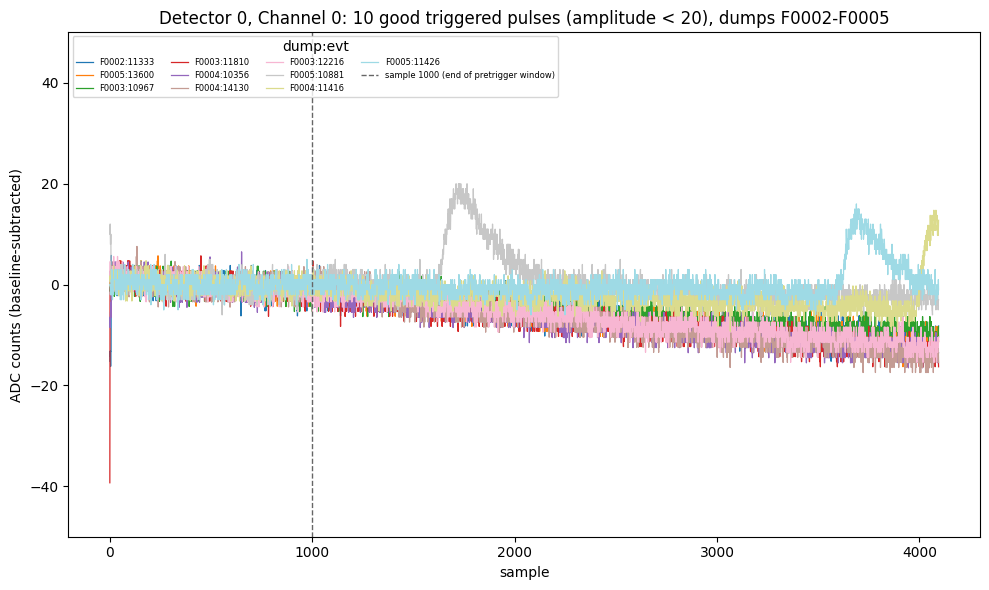

In [4]:
rng = np.random.default_rng(0)
n_show = min(20, len(good_pulse_indices))
show_idx = rng.choice(good_pulse_indices, size=n_show, replace=False)
colors = plt.cm.tab20(np.linspace(0, 1, n_show))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(show_idx, colors):
    trace = pulses[i] - bmean_arr[i]
    label = f"{dump_arr[i]}:{detector_id_arr[i].split('_')[0]}"
    ax.plot(trace, linewidth=0.9, color=color, label=label)

ax.axvline(PRETRIGGER_SAMPLES, color="0.4", linestyle="--", linewidth=1,
           label=f"sample {PRETRIGGER_SAMPLES} (end of pretrigger window)")
# crop both leading-glitch directions (negative, per request; a same-size positive one
# was squashing the scale here too, so capped symmetrically) -- not part of the real pulse
ax.set_ylim(-50, 50)
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Detector {DETECTOR}, Channel {CHANNEL}: {n_show} good triggered pulses "
             f"(amplitude < {MAX_AMPLITUDE}), dumps F0002-F0005")
ax.legend(fontsize=6, ncol=4, loc="upper left", title="dump:evt")
fig.tight_layout()
plt.show()

**Observation:** the pulse onset is *not* at a fixed sample across these traces — rises
land anywhere from roughly sample 1150 out to sample 3050, well past the nominal
pretrigger/post-trigger boundary at sample 1000. There isn't a single "the trigger
happens here" sample for this trigger configuration; onset time itself varies
event-to-event. Worth keeping in mind for any fixed-window pulse-shape assumptions
downstream (e.g. optimal filtering, which per Golwala's Appendix B assumes a known
template start time — a time-offset search, as he describes in B.4, would be needed
here rather than a fixed-position fit).